In [3]:
import os
import pandas as pd
import numpy as np

In [4]:
path = r"E:\company_data_analysis"

print(os.listdir(path))

['benefits.csv', 'companies.csv', 'company_industries.csv', 'company_specialities.csv', 'employee_counts.csv', 'industries.csv', 'job_industries.csv', 'job_skills.csv', 'postings.csv', 'salaries.csv', 'skills.csv']


In [5]:
file_path = os.path.join(path, "postings.csv")

df = pd.read_csv(file_path)

df.head()

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


In [6]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 123849
Columns: 31


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123849 entries, 0 to 123848
Data columns (total 31 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   job_id                      123849 non-null  int64  
 1   company_name                122130 non-null  object 
 2   title                       123849 non-null  object 
 3   description                 123842 non-null  object 
 4   max_salary                  29793 non-null   float64
 5   pay_period                  36073 non-null   object 
 6   location                    123849 non-null  object 
 7   company_id                  122132 non-null  float64
 8   views                       122160 non-null  float64
 9   med_salary                  6280 non-null    float64
 10  min_salary                  29793 non-null   float64
 11  formatted_work_type         123849 non-null  object 
 12  applies                     23320 non-null   float64
 13  original_liste

In [8]:
df.columns

Index(['job_id', 'company_name', 'title', 'description', 'max_salary',
       'pay_period', 'location', 'company_id', 'views', 'med_salary',
       'min_salary', 'formatted_work_type', 'applies', 'original_listed_time',
       'remote_allowed', 'job_posting_url', 'application_url',
       'application_type', 'expiry', 'closed_time',
       'formatted_experience_level', 'skills_desc', 'listed_time',
       'posting_domain', 'sponsored', 'work_type', 'currency',
       'compensation_type', 'normalized_salary', 'zip_code', 'fips'],
      dtype='object')

In [9]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

missing.sort_values("Missing Percentage", ascending=False)

,Missing Values,Missing Percentage
closed_time,122776,99.13
skills_desc,121410,98.03
med_salary,117569,94.93
remote_allowed,108603,87.69
applies,100529,81.17
max_salary,94056,75.94
min_salary,94056,75.94
currency,87776,70.87
compensation_type,87776,70.87
normalized_salary,87776,70.87


In [10]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate job IDs:", df["job_id"].duplicated().sum())

Duplicate rows: 0
Duplicate job IDs: 0


In [11]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
job_id,123849.0,NaN,NaN,NaN,3896402138.074615,84043545.161881,921716.0,3894586595.0,3901998406.0,3904707077.0,3906267224.0
company_name,122130,24428,Liberty Healthcare and Rehabilitation Services,1108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,123849,72521,Sales Manager,673,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,123842,107827,Position Summary: Our Sales Manager has managi...,474,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max_salary,29793.0,NaN,NaN,NaN,91939.423461,701110.138622,1.0,48.28,80000.0,140000.0,120000000.0
pay_period,36073,5,YEARLY,20628,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,123849,8526,United States,8125,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company_id,122132.0,NaN,NaN,NaN,12204012.335015,25541431.65742,1009.0,14352.0,226965.0,8047188.0,103472979.0
views,122160.0,NaN,NaN,NaN,14.618247,85.903598,1.0,3.0,4.0,8.0,9975.0
med_salary,6280.0,NaN,NaN,NaN,22015.619876,52255.873846,0.0,18.94,25.5,2510.5,750000.0


In [12]:
df.head()

,job_id,company_name,title,description,max_salary,pay_period,location,company_id,views,med_salary,...,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,normalized_salary,zip_code,fips
0,921716,Corcoran Sawyer Smith,Marketing Coordinator,Job descriptionA leading real estate firm in N...,20.0,HOURLY,"Princeton, NJ",2774458.0,20.0,NaN,...,Requirements: \n\nWe are seeking a College or ...,1.713398e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,38480.0,8540.0,34021.0
1,1829192,NaN,Mental Health Therapist/Counselor,"At Aspen Therapy and Wellness , we are committ...",50.0,HOURLY,"Fort Collins, CO",NaN,1.0,NaN,...,NaN,1.712858e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,83200.0,80521.0,8069.0
2,10998357,The National Exemplar,Assitant Restaurant Manager,The National Exemplar is accepting application...,65000.0,YEARLY,"Cincinnati, OH",64896719.0,8.0,NaN,...,We are currently accepting resumes for FOH - A...,1.713278e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,55000.0,45202.0,39061.0
3,23221523,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,Senior Associate Attorney - Elder Law / Trusts...,175000.0,YEARLY,"New Hyde Park, NY",766262.0,16.0,NaN,...,This position requires a baseline understandin...,1.712896e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,157500.0,11040.0,36059.0
4,35982263,NaN,Service Technician,Looking for HVAC service tech with experience ...,80000.0,YEARLY,"Burlington, IA",NaN,3.0,NaN,...,NaN,1.713452e+12,NaN,0,FULL_TIME,USD,BASE_SALARY,70000.0,52601.0,19057.0


In [13]:
df_clean = df.copy()

In [14]:
df_clean = df_clean.drop_duplicates(subset="job_id")

print("Rows after removing duplicate job IDs:", len(df_clean))

Rows after removing duplicate job IDs: 123849


In [15]:
df_clean["listed_time"] = pd.to_datetime(
    df_clean["listed_time"],
    errors="coerce"
)

df_clean["listed_time"].head()

0   1970-01-01 00:28:33.397508
1   1970-01-01 00:28:32.857887
2   1970-01-01 00:28:33.277614
3   1970-01-01 00:28:32.895812
4   1970-01-01 00:28:33.451943
Name: listed_time, dtype: datetime64[ns]

In [16]:
df_clean["posted_date"] = df_clean["listed_time"].dt.date
df_clean["posted_year"] = df_clean["listed_time"].dt.year
df_clean["posted_month"] = df_clean["listed_time"].dt.month
df_clean["posted_month_name"] = df_clean["listed_time"].dt.month_name()

In [17]:
salary_cols = [
    "min_salary",
    "med_salary",
    "max_salary",
    "normalized_salary"
]

df_clean[salary_cols].describe()

,min_salary,med_salary,max_salary,normalized_salary
count,2.979300e+04,6280.000000,2.979300e+04,3.607300e+04
mean,6.491085e+04,22015.619876,9.193942e+04,2.053270e+05
std,4.959738e+05,52255.873846,7.011101e+05,5.097627e+06
min,1.000000e+00,0.000000,1.000000e+00,0.000000e+00
25%,3.700000e+01,18.940000,4.828000e+01,5.200000e+04
50%,6.000000e+04,25.500000,8.000000e+04,8.150000e+04
75%,1.000000e+05,2510.500000,1.400000e+05,1.250000e+05
max,8.500000e+07,750000.000000,1.200000e+08,5.356000e+08


In [18]:
print("Work types:")
print(df_clean["formatted_work_type"].value_counts(dropna=False))

print("\nExperience levels:")
print(df_clean["formatted_experience_level"].value_counts(dropna=False))

print("\nRemote allowed:")
print(df_clean["remote_allowed"].value_counts(dropna=False))

Work types:
formatted_work_type
Full-time     98814
Contract      12117
Part-time      9696
Temporary      1190
Internship      983
Volunteer       562
Other           487
Name: count, dtype: int64

Experience levels:
formatted_experience_level
Mid-Senior level    41489
Entry level         36708
NaN                 29409
Associate            9826
Director             3746
Internship           1449
Executive            1222
Name: count, dtype: int64

Remote allowed:
remote_allowed
NaN    108603
1.0     15246
Name: count, dtype: int64


In [19]:
print("Original rows:", len(df))
print("Cleaned rows:", len(df_clean))
print("Columns:", df_clean.shape[1])

Original rows: 123849
Cleaned rows: 123849
Columns: 35


In [20]:
missing = pd.DataFrame({
    "Missing": df_clean.isnull().sum(),
    "Missing %": (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
})

missing = missing[missing["Missing"] > 0].sort_values(
    "Missing %",
    ascending=False
)

missing

,Missing,Missing %
closed_time,122776,99.13
skills_desc,121410,98.03
med_salary,117569,94.93
remote_allowed,108603,87.69
applies,100529,81.17
max_salary,94056,75.94
min_salary,94056,75.94
pay_period,87776,70.87
normalized_salary,87776,70.87
compensation_type,87776,70.87


In [21]:
text_cols = [
    "company_name",
    "location",
    "formatted_work_type",
    "formatted_experience_level",
    "currency"
]

for col in text_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna("Unknown")

In [22]:
df_clean["remote_status"] = df_clean["remote_allowed"].map({
    1: "Remote",
    0: "Not Remote"
}).fillna("Unknown")

df_clean["remote_status"].value_counts()

remote_status
Unknown    108603
Remote      15246
Name: count, dtype: int64

In [23]:
df_clean[["views", "applies"]].isnull().sum()

views        1689
applies    100529
dtype: int64

In [24]:
df_clean[["views", "applies"]].describe()

,views,applies
count,122160.000000,23320.000000
mean,14.618247,10.591981
std,85.903598,29.047395
min,1.000000,1.000000
25%,3.000000,1.000000
50%,4.000000,3.000000
75%,8.000000,8.000000
max,9975.000000,967.000000


In [25]:
df_clean.isnull().sum().sort_values(ascending=False).head(15)

closed_time          122776
skills_desc          121410
med_salary           117569
remote_allowed       108603
applies              100529
min_salary            94056
max_salary            94056
compensation_type     87776
pay_period            87776
normalized_salary     87776
posting_domain        39968
application_url       36665
fips                  27415
zip_code              20872
company_id             1717
dtype: int64

In [26]:
df_clean[["views", "applies"]].describe()

,views,applies
count,122160.000000,23320.000000
mean,14.618247,10.591981
std,85.903598,29.047395
min,1.000000,1.000000
25%,3.000000,1.000000
50%,4.000000,3.000000
75%,8.000000,8.000000
max,9975.000000,967.000000


In [27]:
df_clean.isnull().sum().sort_values(ascending=False).head(15)

closed_time          122776
skills_desc          121410
med_salary           117569
remote_allowed       108603
applies              100529
min_salary            94056
max_salary            94056
compensation_type     87776
pay_period            87776
normalized_salary     87776
posting_domain        39968
application_url       36665
fips                  27415
zip_code              20872
company_id             1717
dtype: int64

In [28]:
df_clean[["views", "applies"]].describe()

,views,applies
count,122160.000000,23320.000000
mean,14.618247,10.591981
std,85.903598,29.047395
min,1.000000,1.000000
25%,3.000000,1.000000
50%,4.000000,3.000000
75%,8.000000,8.000000
max,9975.000000,967.000000


In [29]:
df_clean.isnull().sum().sort_values(ascending=False).head(15)

closed_time          122776
skills_desc          121410
med_salary           117569
remote_allowed       108603
applies              100529
min_salary            94056
max_salary            94056
compensation_type     87776
pay_period            87776
normalized_salary     87776
posting_domain        39968
application_url       36665
fips                  27415
zip_code              20872
company_id             1717
dtype: int64

In [30]:
df_clean["salary_available"] = (
    df_clean[["min_salary", "med_salary", "max_salary"]]
    .notna()
    .any(axis=1)
)

df_clean["salary_available"].value_counts()

salary_available
False    87776
True     36073
Name: count, dtype: int64

In [31]:
df_clean["salary_estimate"] = df_clean["med_salary"]

mask = (
    df_clean["salary_estimate"].isna()
    & df_clean["min_salary"].notna()
    & df_clean["max_salary"].notna()
)

df_clean.loc[mask, "salary_estimate"] = (
    df_clean.loc[mask, "min_salary"]
    + df_clean.loc[mask, "max_salary"]
) / 2

In [32]:
df_clean["salary_estimate"].describe()

count    3.607300e+04
mean     6.860472e+04
std      5.445734e+05
min      0.000000e+00
25%      3.000000e+01
50%      5.825000e+04
75%      1.100000e+05
max      1.025000e+08
Name: salary_estimate, dtype: float64

In [33]:
df_clean[
    ["title", "company_name", "location", "salary_estimate", "currency"]
].sort_values(
    "salary_estimate",
    ascending=False
).head(10)

,title,company_name,location,salary_estimate,currency
94881,Marketing Director,EOX Vantage,"Cleveland, OH",102500000.0,USD
116367,Quantitative Researcher,Goliath Partners,Greater Chicago Area,950000.0,USD
4908,Partner (& Groups w/ Portable Business for Top...,"Platinum Legal Search Group, LLC","New York, NY",925000.0,USD
4781,Partner (& Groups w/ Portable Business for Top...,"Platinum Legal Search Group, LLC",San Francisco Bay Area,925000.0,USD
91967,"Corporate, Litigation, Intellectual Property ,...","Platinum Legal Search Group, LLC","Richmond, VA",925000.0,USD
4735,Partner (& Groups w/ Portable Business for Top...,"Platinum Legal Search Group, LLC","Pennsylvania, United States",925000.0,USD
113069,Head of Front Office Technology,Goldman Lloyds,New York City Metropolitan Area,875000.0,USD
117057,Quantitative Researcher,Goliath Partners,"New York, United States",825000.0,USD
54411,Senior Sales Account Executive - Enterprise,Emburse,United States,750000.0,USD
115360,Python Developer,Radley James,"Chicago, IL",750000.0,USD


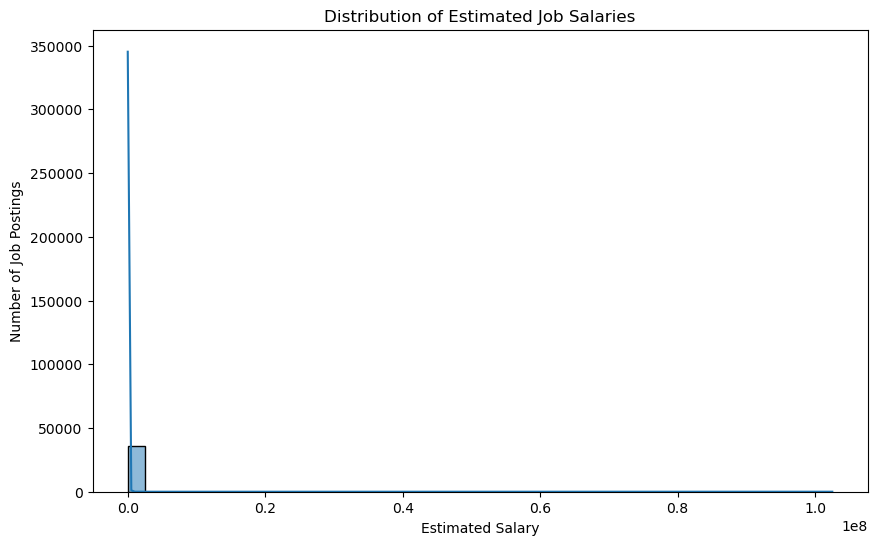

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_clean,
    x="salary_estimate",
    bins=40,
    kde=True
)

plt.title("Distribution of Estimated Job Salaries")
plt.xlabel("Estimated Salary")
plt.ylabel("Number of Job Postings")
plt.show()

In [35]:
df_clean["salary_estimate"].quantile([0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

0.25        30.0
0.50     58250.0
0.75    110000.0
0.90    160850.0
0.95    195000.0
0.99    288933.5
Name: salary_estimate, dtype: float64

In [36]:
work_type = (
    df_clean["formatted_work_type"]
    .value_counts()
    .reset_index()
)

work_type.columns = ["Work Type", "Job Postings"]

work_type

,Work Type,Job Postings
0,Full-time,98814
1,Contract,12117
2,Part-time,9696
3,Temporary,1190
4,Internship,983
5,Volunteer,562
6,Other,487


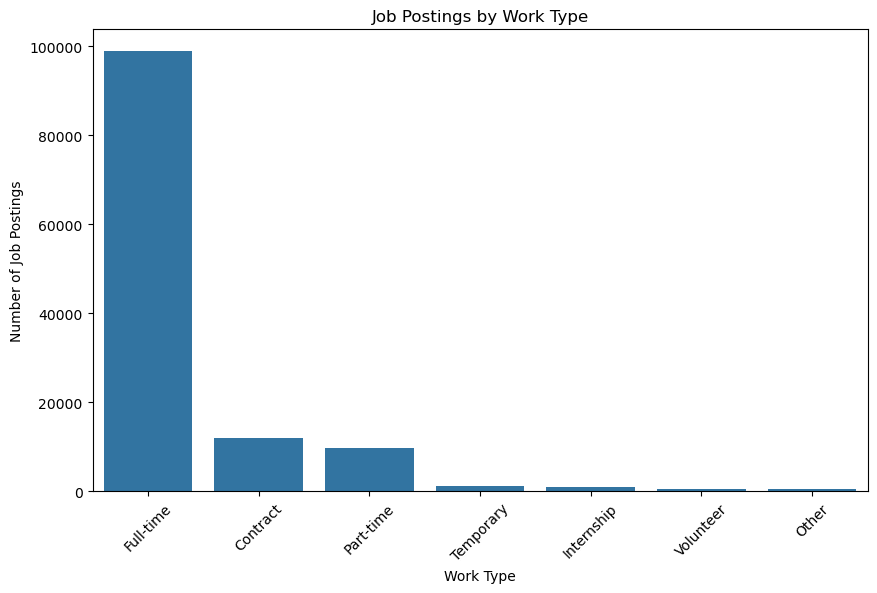

In [37]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=work_type,
    x="Work Type",
    y="Job Postings"
)

plt.title("Job Postings by Work Type")
plt.xlabel("Work Type")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45)
plt.show()

In [38]:
experience = (
    df_clean["formatted_experience_level"]
    .value_counts()
    .reset_index()
)

experience.columns = ["Experience Level", "Job Postings"]

experience

,Experience Level,Job Postings
0,Mid-Senior level,41489
1,Entry level,36708
2,Unknown,29409
3,Associate,9826
4,Director,3746
5,Internship,1449
6,Executive,1222


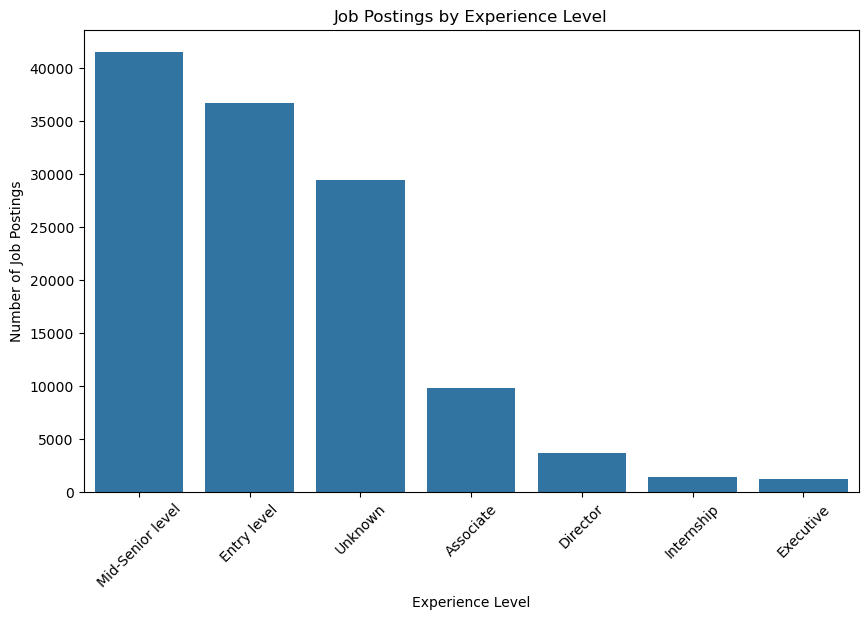

In [39]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=experience,
    x="Experience Level",
    y="Job Postings"
)

plt.title("Job Postings by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45)
plt.show()

In [40]:
remote = (
    df_clean["remote_status"]
    .value_counts()
    .reset_index()
)

remote.columns = ["Remote Status", "Job Postings"]

remote

,Remote Status,Job Postings
0,Unknown,108603
1,Remote,15246


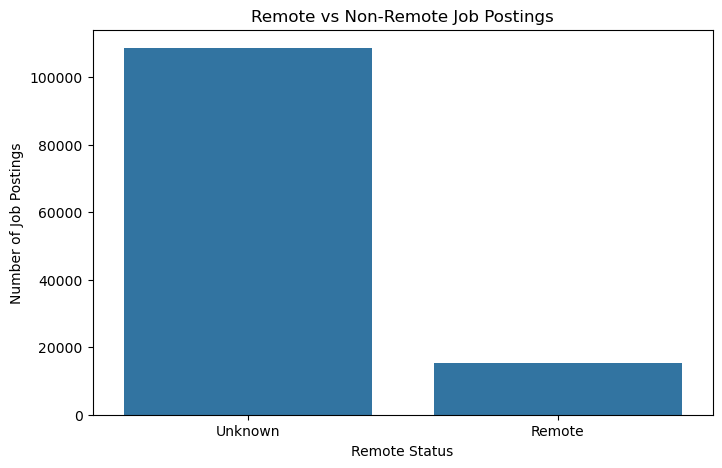

In [41]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=remote,
    x="Remote Status",
    y="Job Postings"
)

plt.title("Remote vs Non-Remote Job Postings")
plt.xlabel("Remote Status")
plt.ylabel("Number of Job Postings")
plt.show()

In [42]:
top_titles = (
    df_clean["title"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_titles.columns = ["Job Title", "Job Postings"]

top_titles

,Job Title,Job Postings
0,Sales Manager,673
1,Customer Service Representative,373
2,Project Manager,354
3,Administrative Assistant,254
4,Senior Accountant,238
5,Executive Assistant,228
6,Salesperson,211
7,Registered Nurse,210
8,Receptionist,204
9,Staff Accountant,200


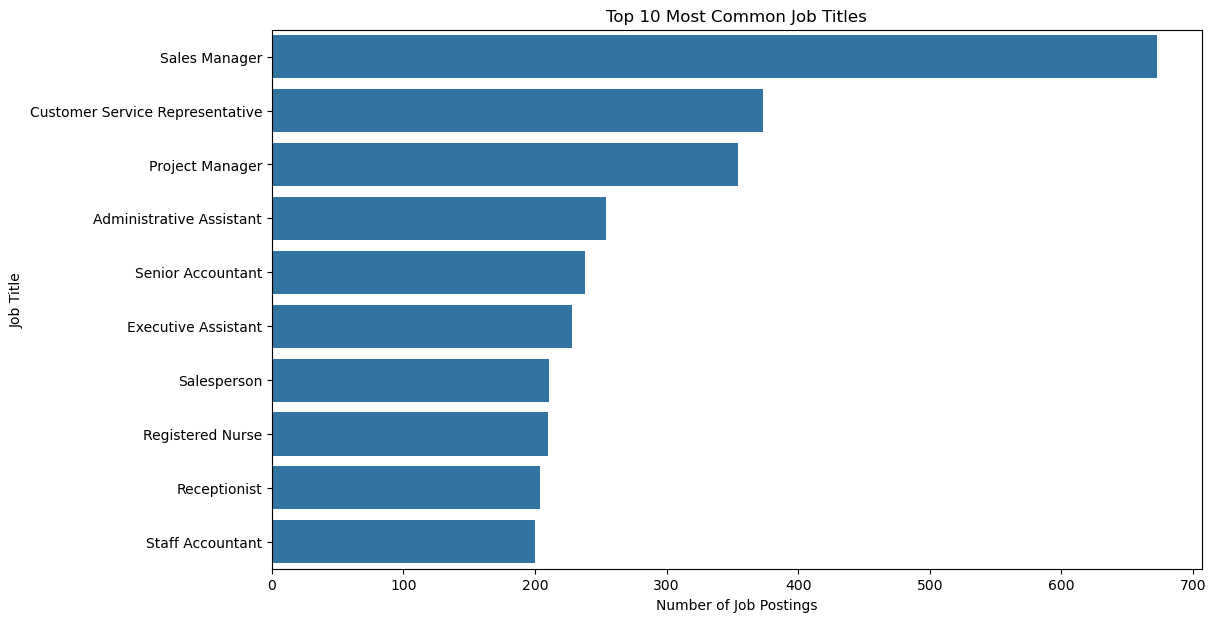

In [43]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_titles,
    x="Job Postings",
    y="Job Title"
)

plt.title("Top 10 Most Common Job Titles")
plt.xlabel("Number of Job Postings")
plt.ylabel("Job Title")
plt.show()

In [44]:
top_locations = (
    df_clean["location"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_locations.columns = ["Location", "Job Postings"]

top_locations

,Location,Job Postings
0,United States,8125
1,"New York, NY",2756
2,"Chicago, IL",1834
3,"Houston, TX",1762
4,"Dallas, TX",1383
5,"Atlanta, GA",1363
6,"Boston, MA",1176
7,"Austin, TX",1083
8,"Charlotte, NC",1075
9,"Phoenix, AZ",1059


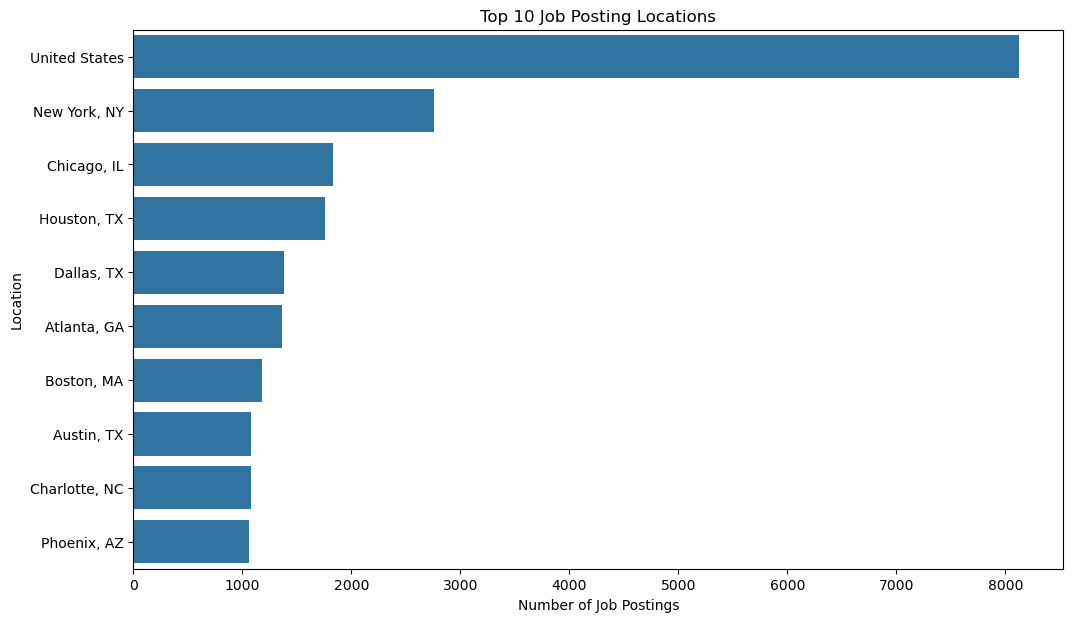

In [45]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_locations,
    x="Job Postings",
    y="Location"
)

plt.title("Top 10 Job Posting Locations")
plt.xlabel("Number of Job Postings")
plt.ylabel("Location")
plt.show()

In [46]:
top_companies = (
    df_clean["company_name"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_companies.columns = ["Company", "Job Postings"]

top_companies

,Company,Job Postings
0,Unknown,1719
1,Liberty Healthcare and Rehabilitation Services,1108
2,The Job Network,1003
3,J. Galt,604
4,TEKsystems,529
5,"Lowe's Companies, Inc.",527
6,Ingersoll Rand,517
7,Capital One,496
8,Cogent Communications,476
9,Insight Global,418


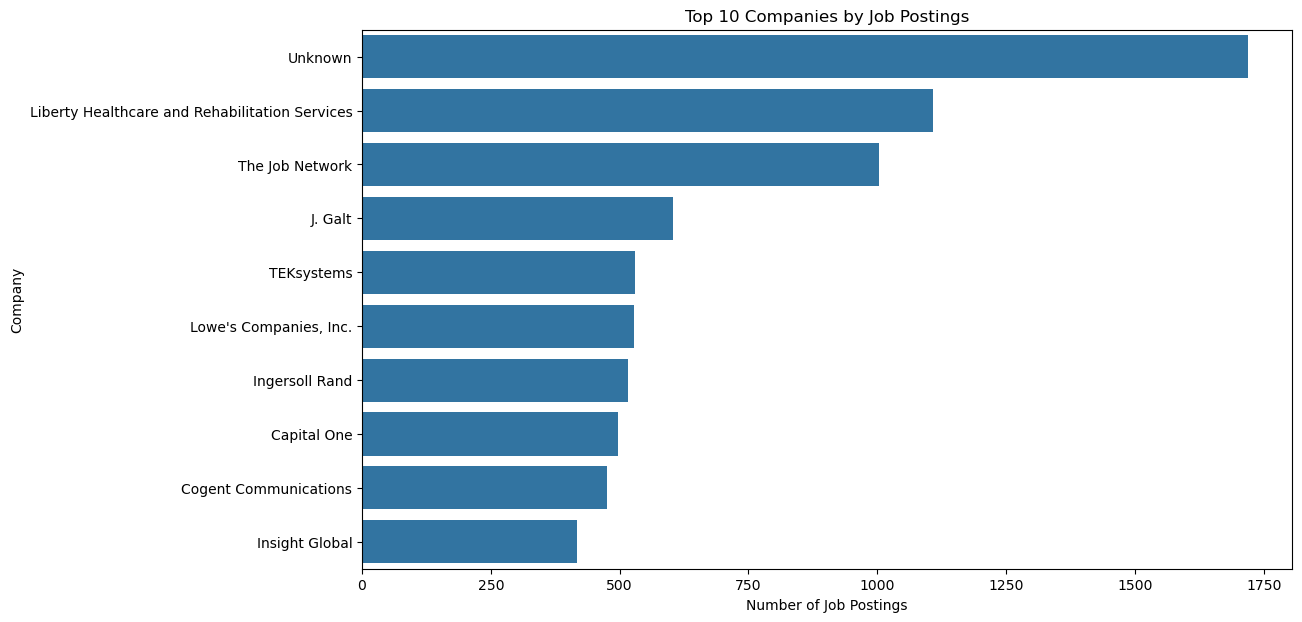

In [47]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_companies,
    x="Job Postings",
    y="Company"
)

plt.title("Top 10 Companies by Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("Company")
plt.show()

In [48]:
engagement = df_clean[["views", "applies"]].dropna()

engagement.describe()

,views,applies
count,23319.000000,23319.000000
mean,55.555984,10.592392
std,189.885916,29.047950
min,1.000000,1.000000
25%,11.000000,1.000000
50%,23.000000,3.000000
75%,49.000000,8.000000
max,9975.000000,967.000000


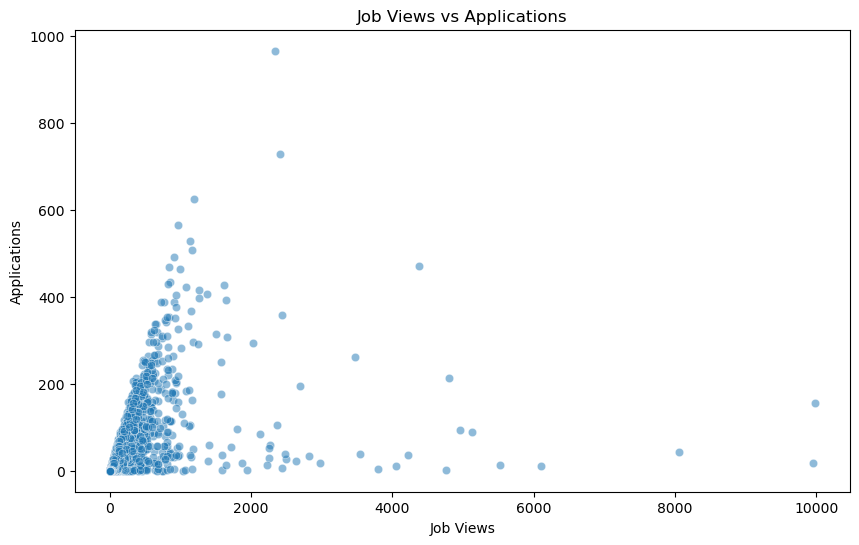

In [49]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=engagement,
    x="views",
    y="applies",
    alpha=0.5
)

plt.title("Job Views vs Applications")
plt.xlabel("Job Views")
plt.ylabel("Applications")
plt.show()

In [50]:
correlation = engagement["views"].corr(engagement["applies"])

print("Views vs Applications Correlation:", round(correlation, 3))

Views vs Applications Correlation: 0.494


In [51]:
df_clean["application_rate"] = np.where(
    df_clean["views"] > 0,
    (df_clean["applies"] / df_clean["views"]) * 100,
    np.nan
)

In [52]:
df_clean["application_rate"].describe()

count    23319.000000
mean        17.645109
std         11.297970
min          0.063118
25%          9.090909
50%         14.864865
75%         23.529412
max        100.000000
Name: application_rate, dtype: float64

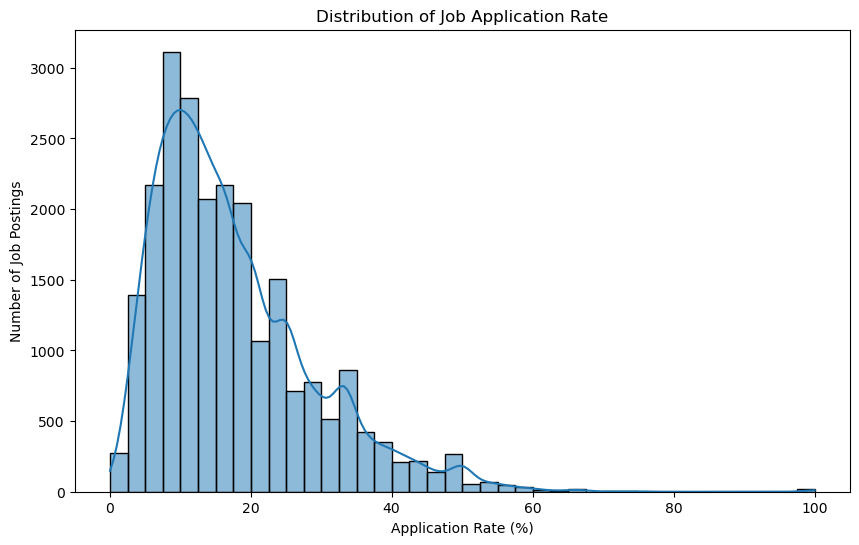

In [53]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_clean,
    x="application_rate",
    bins=40,
    kde=True
)

plt.title("Distribution of Job Application Rate")
plt.xlabel("Application Rate (%)")
plt.ylabel("Number of Job Postings")
plt.show()

In [54]:
# Load skills data
job_skills = pd.read_csv(r"E:\company_data_analysis\job_skills.csv")
skills = pd.read_csv(r"E:\company_data_analysis\skills.csv")

print("Job skills shape:", job_skills.shape)
print("Skills shape:", skills.shape)

Job skills shape: (213768, 2)
Skills shape: (35, 2)


In [55]:
job_skills_named = job_skills.merge(
    skills,
    on="skill_abr",
    how="left"
)

job_skills_named.head()

,job_id,skill_abr,skill_name
0,3884428798,MRKT,Marketing
1,3884428798,PR,Public Relations
2,3884428798,WRT,Writing/Editing
3,3887473071,SALE,Sales
4,3887465684,FIN,Finance


In [56]:
top_skills = (
    job_skills_named["skill_name"]
    .value_counts()
    .reset_index()
)

top_skills.columns = ["Skill", "Job Postings"]

top_skills.head(15)

,Skill,Job Postings
0,Information Technology,26137
1,Sales,22475
2,Management,20861
3,Manufacturing,18185
4,Health Care Provider,17369
5,Business Development,14290
6,Engineering,13009
7,Other,12608
8,Finance,8540
9,Marketing,5525


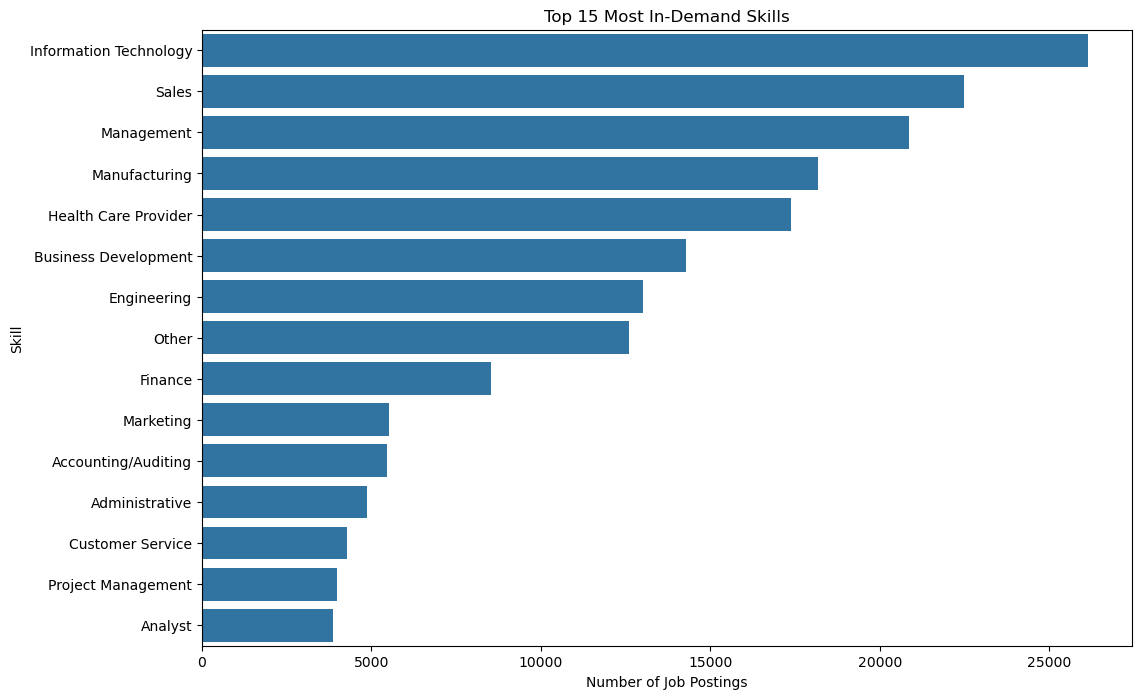

In [57]:
plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_skills.head(15),
    x="Job Postings",
    y="Skill"
)

plt.title("Top 15 Most In-Demand Skills")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")
plt.show()

In [58]:
skills_analysis = job_skills_named.merge(
    df_clean[
        [
            "job_id",
            "title",
            "company_name",
            "location",
            "salary_estimate",
            "formatted_experience_level",
            "formatted_work_type",
            "remote_status"
        ]
    ],
    on="job_id",
    how="inner"
)

print("Rows:", skills_analysis.shape[0])
skills_analysis.head()

Rows: 205778


,job_id,skill_abr,skill_name,title,company_name,location,salary_estimate,formatted_experience_level,formatted_work_type,remote_status
0,3884428798,MRKT,Marketing,Public Relations Intern,ASSOULINE,New York City Metropolitan Area,20.0,Internship,Internship,Unknown
1,3884428798,PR,Public Relations,Public Relations Intern,ASSOULINE,New York City Metropolitan Area,20.0,Internship,Internship,Unknown
2,3884428798,WRT,Writing/Editing,Public Relations Intern,ASSOULINE,New York City Metropolitan Area,20.0,Internship,Internship,Unknown
3,3887473071,SALE,Sales,Outside Sales Consultant,Renewal by Andersen Metro & Midwest,Atlanta Metropolitan Area,NaN,Mid-Senior level,Full-time,Unknown
4,3887465684,FIN,Finance,Seasonal Teller Trainee - Montgomery County( H...,Sandy Spring Bank,"Olney, MD",NaN,Unknown,Temporary,Unknown


In [59]:
skill_experience = (
    skills_analysis
    .groupby(
        ["formatted_experience_level", "skill_name"]
    )
    .size()
    .reset_index(name="Job Postings")
)

skill_experience.sort_values(
    "Job Postings",
    ascending=False
).head(20)

,formatted_experience_level,skill_name,Job Postings
191,Mid-Senior level,Information Technology,10169
88,Entry level,Management,9218
89,Entry level,Manufacturing,8436
204,Mid-Senior level,Sales,6962
86,Entry level,Information Technology,6595
226,Unknown,Information Technology,6179
84,Entry level,Health Care Provider,6127
99,Entry level,Sales,5900
189,Mid-Senior level,Health Care Provider,5660
193,Mid-Senior level,Management,5410


In [60]:
tech_skills = [
    "Python",
    "SQL",
    "R",
    "Excel",
    "Tableau",
    "Power BI",
    "Machine Learning",
    "TensorFlow",
    "PyTorch"
]

tech_skill_analysis = skills_analysis[
    skills_analysis["skill_name"].isin(tech_skills)
]

tech_skill_analysis["skill_name"].value_counts()

Series([], Name: count, dtype: int64)

In [61]:
salary_by_skill = (
    skills_analysis
    .dropna(subset=["salary_estimate"])
    .groupby("skill_name")
    .agg(
        Average_Salary=("salary_estimate", "mean"),
        Job_Postings=("job_id", "count")
    )
    .sort_values("Average_Salary", ascending=False)
)

salary_by_skill.head(15)

,Average_Salary,Job_Postings
skill_name,,
Marketing,145873.918926,1644
Product Management,129050.611421,475
Legal,123063.778388,980
Strategy/Planning,114903.004440,473
Engineering,99159.949925,3778
Sales,95011.683202,5648
Consulting,92175.714818,795
Project Management,91285.871959,1442
Finance,88772.541287,2936


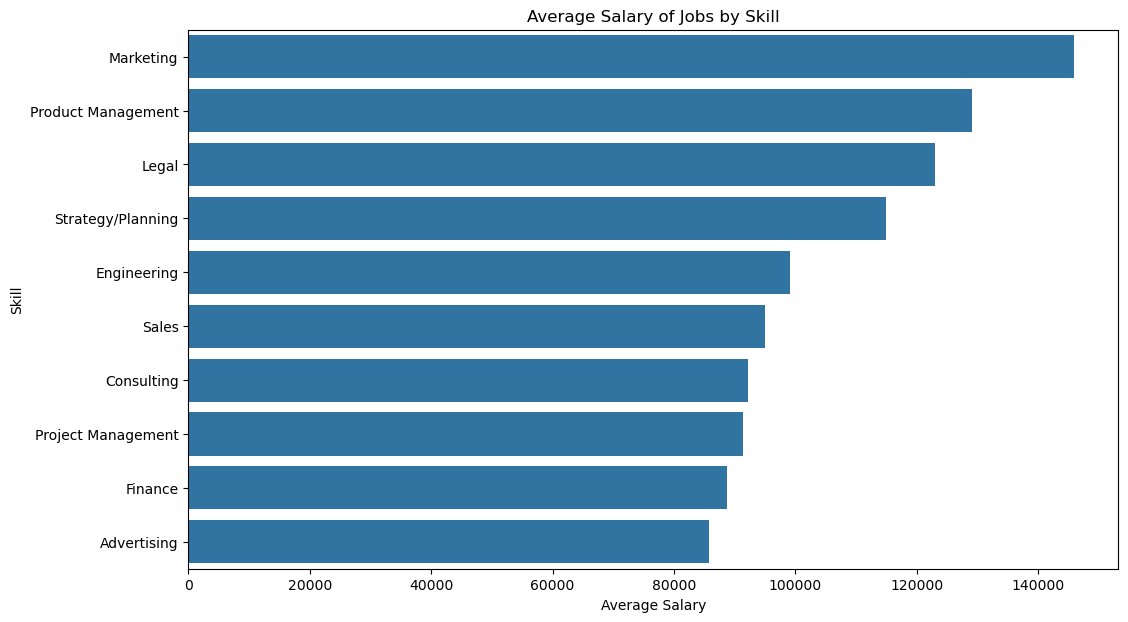

In [62]:
top_salary_skills = salary_by_skill[
    salary_by_skill["Job_Postings"] >= 50
].head(10).reset_index()

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_salary_skills,
    x="Average_Salary",
    y="skill_name"
)

plt.title("Average Salary of Jobs by Skill")
plt.xlabel("Average Salary")
plt.ylabel("Skill")
plt.show()

In [63]:
job_industries = pd.read_csv(
    r"E:\company_data_analysis\job_industries.csv"
)

industries = pd.read_csv(
    r"E:\company_data_analysis\industries.csv"
)

print("Job industries:", job_industries.shape)
print("Industries:", industries.shape)

Job industries: (164808, 2)
Industries: (422, 2)


In [64]:
print(job_industries.columns)
print(industries.columns)

Index(['job_id', 'industry_id'], dtype='object')
Index(['industry_id', 'industry_name'], dtype='object')


In [65]:
job_industries_named = job_industries.merge(
    industries,
    on="industry_id",
    how="left"
)

job_industries_named.head()

,job_id,industry_id,industry_name
0,3884428798,82,Book and Periodical Publishing
1,3887473071,48,Construction
2,3887465684,41,Banking
3,3887467939,82,Book and Periodical Publishing
4,3887467939,80,Advertising Services


In [66]:
top_industries = (
    job_industries_named["industry_name"]
    .value_counts()
    .reset_index()
)

top_industries.columns = ["Industry", "Job Postings"]

top_industries.head(15)

,Industry,Job Postings
0,Hospitals and Health Care,18326
1,Retail,11033
2,IT Services and IT Consulting,10396
3,Staffing and Recruiting,9005
4,Financial Services,8535
5,Software Development,5091
6,Manufacturing,3689
7,Construction,3445
8,Banking,2923
9,Insurance,2673


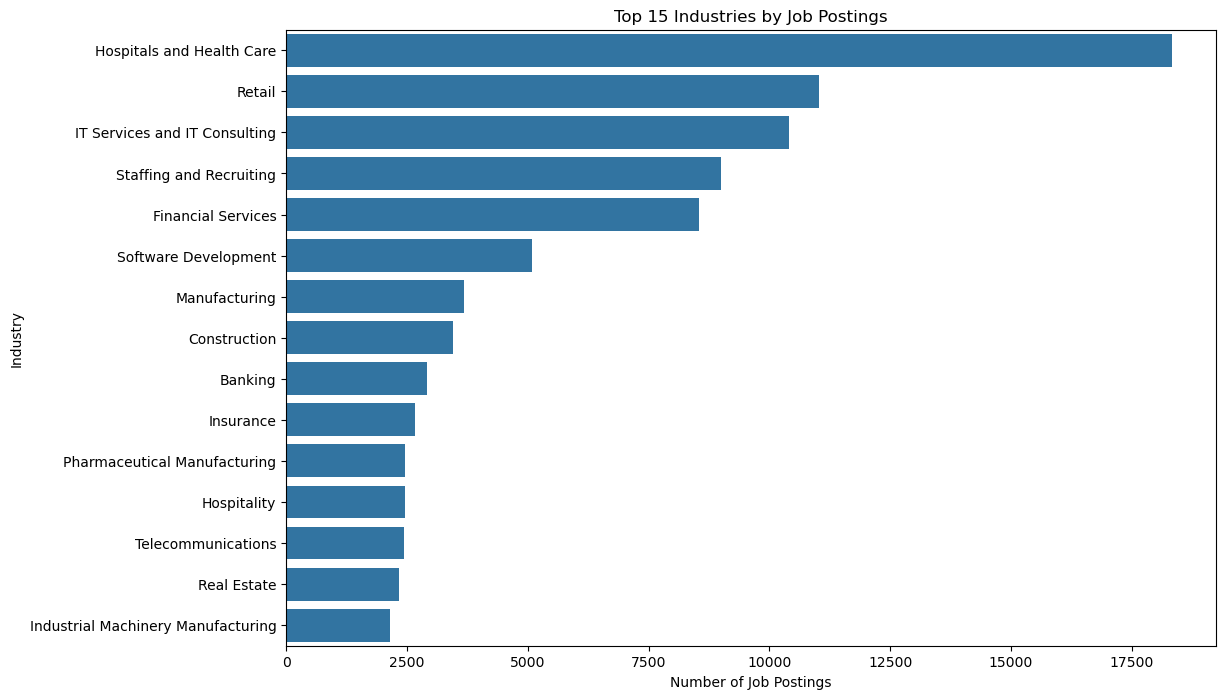

In [67]:
plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_industries.head(15),
    x="Job Postings",
    y="Industry"
)

plt.title("Top 15 Industries by Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("Industry")
plt.show()

In [68]:
industry_salary = job_industries_named.merge(
    df_clean[
        ["job_id", "salary_estimate"]
    ],
    on="job_id",
    how="inner"
)

industry_salary_summary = (
    industry_salary
    .dropna(subset=["salary_estimate"])
    .groupby("industry_name")
    .agg(
        Average_Salary=("salary_estimate", "mean"),
        Job_Postings=("job_id", "count")
    )
    .sort_values("Average_Salary", ascending=False)
)

industry_salary_summary.head(15)

,Average_Salary,Job_Postings
industry_name,,
Real Estate Agents and Brokers,350000.000000,2
Animation and Post-production,257500.000000,1
Capital Markets,204489.696429,84
Alternative Dispute Resolution,201000.000000,7
"Movies, Videos, and Sound",190168.636667,18
Software Development,187736.658088,1710
Climate Technology Product Manufacturing,180000.000000,5
Transportation Equipment Manufacturing,179680.000000,1
Blockchain Services,168750.000000,2


In [69]:
industry_salary_filtered = (
    industry_salary_summary[
        industry_salary_summary["Job_Postings"] >= 50
    ]
    .head(10)
    .reset_index()
)

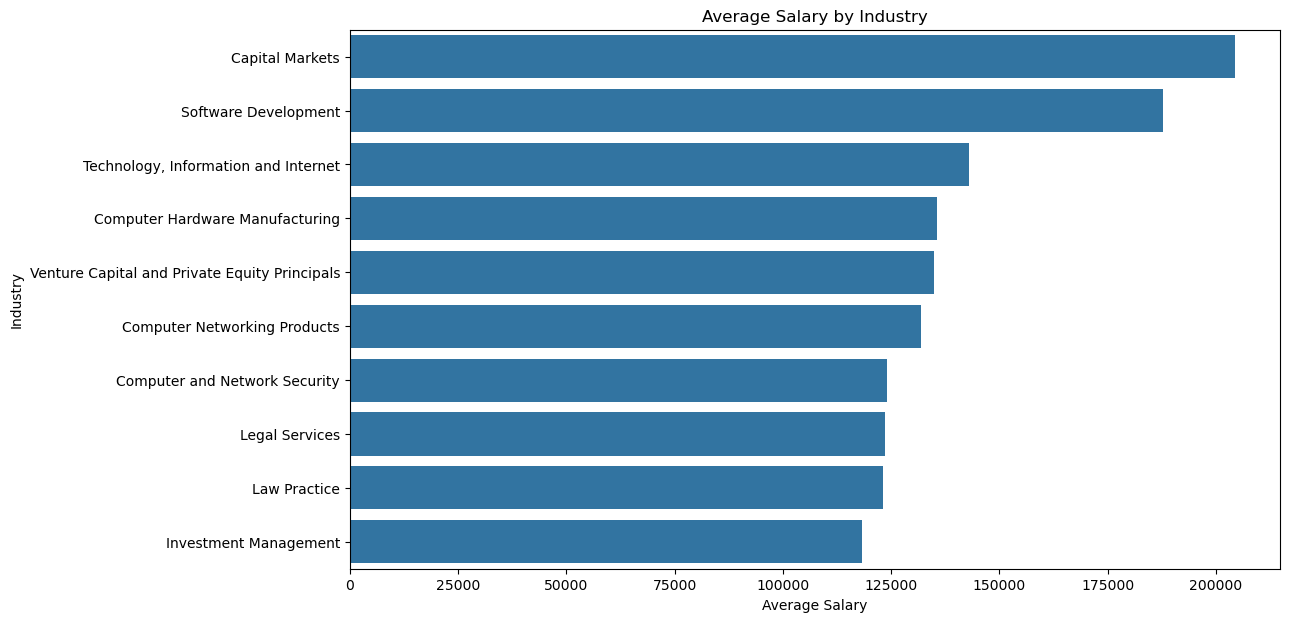

In [70]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=industry_salary_filtered,
    x="Average_Salary",
    y="industry_name"
)

plt.title("Average Salary by Industry")
plt.xlabel("Average Salary")
plt.ylabel("Industry")
plt.show()

In [71]:
companies = pd.read_csv(
    r"E:\company_data_analysis\companies.csv"
)

employee_counts = pd.read_csv(
    r"E:\company_data_analysis\employee_counts.csv"
)

print("Companies:", companies.shape)
print("Employee counts:", employee_counts.shape)

Companies: (24473, 10)
Employee counts: (35787, 4)


In [72]:
print("Companies columns:")
print(companies.columns.tolist())

print("\nEmployee counts columns:")
print(employee_counts.columns.tolist())

Companies columns:
['company_id', 'name', 'description', 'company_size', 'state', 'country', 'city', 'zip_code', 'address', 'url']

Employee counts columns:
['company_id', 'employee_count', 'follower_count', 'time_recorded']


In [73]:
companies.head()

,company_id,name,description,company_size,state,country,city,zip_code,address,url
0,1009,IBM,"At IBM, we do more than work. We create. We cr...",7.0,NY,US,"Armonk, New York",10504,International Business Machines Corp.,https://www.linkedin.com/company/ibm
1,1016,GE HealthCare,Every day millions of people feel the impact o...,7.0,0,US,Chicago,0,-,https://www.linkedin.com/company/gehealthcare
2,1025,Hewlett Packard Enterprise,Official LinkedIn of Hewlett Packard Enterpris...,7.0,Texas,US,Houston,77389,1701 E Mossy Oaks Rd Spring,https://www.linkedin.com/company/hewlett-packa...
3,1028,Oracle,We’re a cloud technology company that provides...,7.0,Texas,US,Austin,78741,2300 Oracle Way,https://www.linkedin.com/company/oracle
4,1033,Accenture,Accenture is a leading global professional ser...,7.0,0,IE,Dublin 2,0,Grand Canal Harbour,https://www.linkedin.com/company/accenture


In [74]:
employee_counts.head()

,company_id,employee_count,follower_count,time_recorded
0,391906,186,32508,1712346173
1,22292832,311,4471,1712346173
2,20300,1053,6554,1712346173
3,3570660,383,35241,1712346173
4,878353,52,26397,1712346173


In [75]:
print("Company IDs in companies:",
      companies["company_id"].nunique())

print("Company IDs in employee counts:",
      employee_counts["company_id"].nunique())

Company IDs in companies: 24473
Company IDs in employee counts: 24473


In [76]:
company_analysis = companies.merge(
    employee_counts,
    on="company_id",
    how="left"
)

company_analysis.head()

,company_id,name,description,company_size,state,country,city,zip_code,address,url,employee_count,follower_count,time_recorded
0,1009,IBM,"At IBM, we do more than work. We create. We cr...",7.0,NY,US,"Armonk, New York",10504,International Business Machines Corp.,https://www.linkedin.com/company/ibm,314102,16253625,1712378162
1,1009,IBM,"At IBM, we do more than work. We create. We cr...",7.0,NY,US,"Armonk, New York",10504,International Business Machines Corp.,https://www.linkedin.com/company/ibm,313142,16309464,1713392385
2,1009,IBM,"At IBM, we do more than work. We create. We cr...",7.0,NY,US,"Armonk, New York",10504,International Business Machines Corp.,https://www.linkedin.com/company/ibm,313147,16309985,1713402495
3,1009,IBM,"At IBM, we do more than work. We create. We cr...",7.0,NY,US,"Armonk, New York",10504,International Business Machines Corp.,https://www.linkedin.com/company/ibm,311223,16314846,1713501255
4,1016,GE HealthCare,Every day millions of people feel the impact o...,7.0,0,US,Chicago,0,-,https://www.linkedin.com/company/gehealthcare,56873,2185368,1712382540


In [77]:
company_analysis.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
company_id,35787.0,NaN,NaN,NaN,16682540.689636,29247215.542959,1009.0,60596.5,1339209.0,15440915.0,103472979.0
name,35786,24428,Confidential,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,35455,24164,Welcome to LHH!\n\nWe're a global leader in HR...,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company_size,32930.0,NaN,NaN,NaN,4.050714,2.066695,1.0,2.0,4.0,6.0,7.0
state,35764,788,0,3041,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,35787,81,US,31588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,35786,4124,New York,1769,NaN,NaN,NaN,NaN,NaN,NaN,NaN
zip_code,35754,7779,0,4090,NaN,NaN,NaN,NaN,NaN,NaN,NaN
address,35765,19476,0,5018,NaN,NaN,NaN,NaN,NaN,NaN,NaN
url,35787,24473,https://www.linkedin.com/company/lhhworldwide,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [78]:
company_jobs = df_clean.merge(
    company_analysis,
    on="company_id",
    how="left",
    suffixes=("", "_company")
)

print("Rows:", company_jobs.shape[0])

Rows: 446571


In [79]:
company_job_counts = (
    company_jobs
    .groupby("company_name")
    .size()
    .reset_index(name="Job Postings")
    .sort_values("Job Postings", ascending=False)
)

company_job_counts.head(15)

,company_name,Job Postings
10829,Insight Global,4598
12688,"Lowe's Companies, Inc.",4216
3975,Capital One,3968
20360,TEKsystems,3703
1284,Amazon,3430
13024,Macy's,3330
23434,Wells Fargo,3104
10773,Ingersoll Rand,3102
4577,Circle K,3048
11108,J. Galt,3020


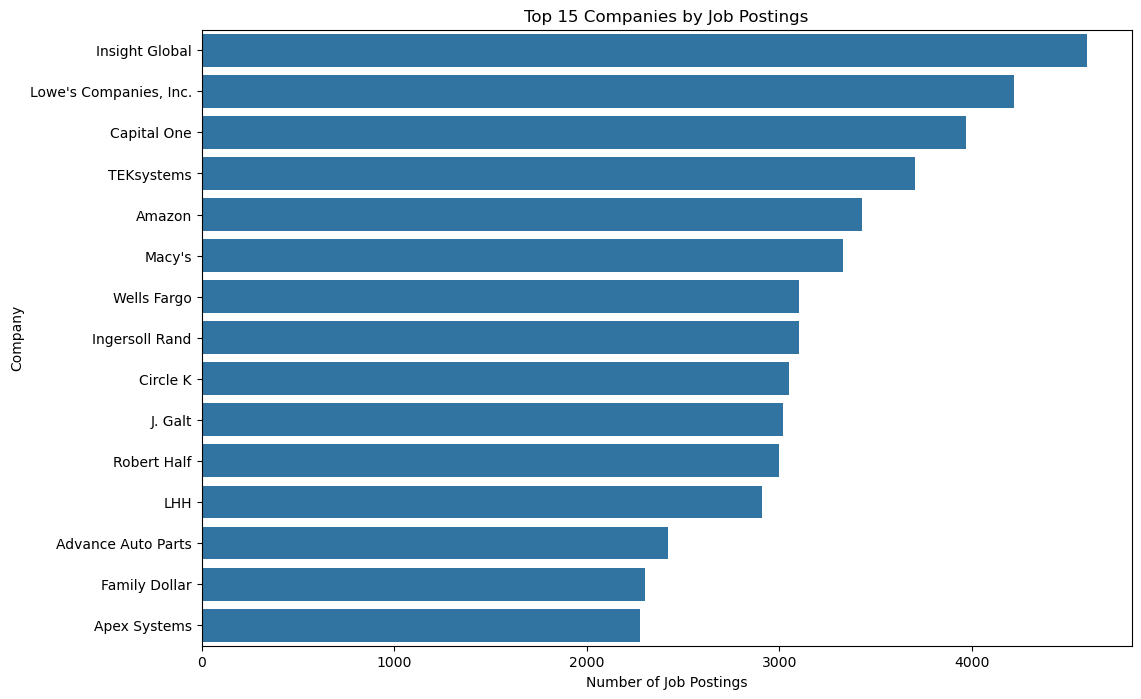

In [80]:
plt.figure(figsize=(12, 8))

sns.barplot(
    data=company_job_counts.head(15),
    x="Job Postings",
    y="company_name"
)

plt.title("Top 15 Companies by Job Postings")
plt.xlabel("Number of Job Postings")
plt.ylabel("Company")
plt.show()

In [81]:
experience_salary = (
    df_clean
    .dropna(subset=["salary_estimate"])
    .groupby("formatted_experience_level")
    .agg(
        Average_Salary=("salary_estimate", "mean"),
        Median_Salary=("salary_estimate", "median"),
        Job_Postings=("job_id", "count")
    )
    .sort_values("Average_Salary", ascending=False)
)

experience_salary

,Average_Salary,Median_Salary,Job_Postings
formatted_experience_level,,,
Executive,191392.007029,190000.00,382
Director,164573.318348,165000.00,1268
Mid-Senior level,81298.400114,85000.00,12909
Unknown,80970.265862,62500.00,8119
Associate,52453.509018,56600.00,3891
Entry level,30511.073220,29.86,9126
Internship,9439.538228,24.00,378


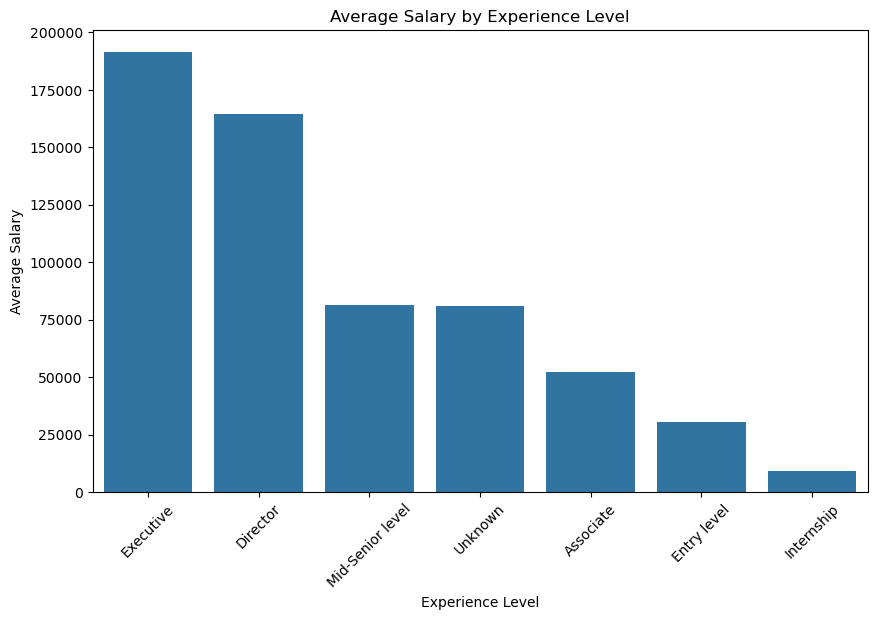

In [82]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=experience_salary.reset_index(),
    x="formatted_experience_level",
    y="Average_Salary"
)

plt.title("Average Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Average Salary")
plt.xticks(rotation=45)
plt.show()

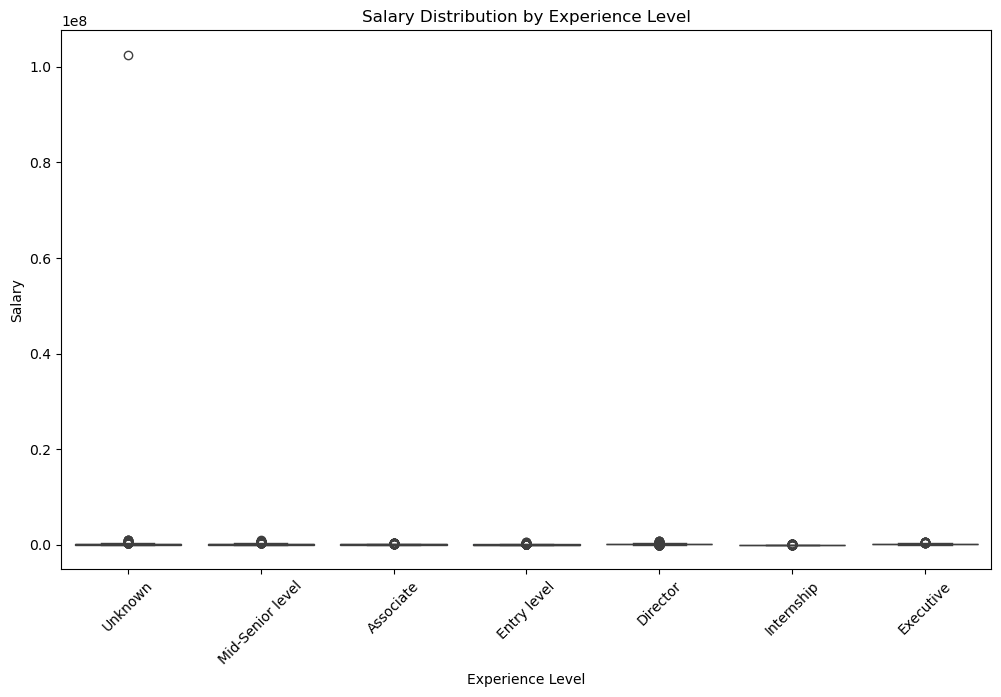

In [83]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=df_clean.dropna(subset=["salary_estimate"]),
    x="formatted_experience_level",
    y="salary_estimate"
)

plt.title("Salary Distribution by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Salary")
plt.xticks(rotation=45)
plt.show()

In [85]:
remote_experience = pd.crosstab(
    df_clean["formatted_experience_level"],
    df_clean["remote_status"]
)

remote_experience

remote_status,Remote,Unknown
formatted_experience_level,,
Associate,1176,8650
Director,670,3076
Entry level,1947,34761
Executive,229,993
Internship,90,1359
Mid-Senior level,6377,35112
Unknown,4757,24652


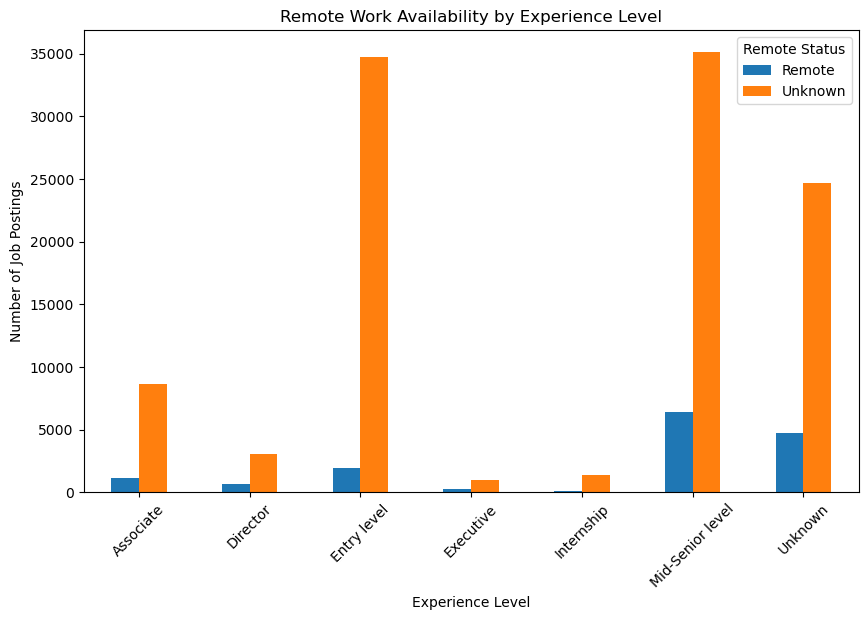

In [86]:
remote_experience.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Remote Work Availability by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45)
plt.legend(title="Remote Status")
plt.show()

In [87]:
df_clean.to_csv(
    r"E:\company_data_analysis\cleaned_postings.csv",
    index=False
)

In [88]:
skills_analysis.to_csv(
    r"E:\company_data_analysis\skills_analysis.csv",
    index=False
)

job_industries_named.to_csv(
    r"E:\company_data_analysis\job_industries_named.csv",
    index=False
)

In [89]:
df_clean.to_csv(
    r"E:\company_data_analysis\cleaned_postings.csv",
    index=False
)

In [90]:
import os

os.path.exists(r"E:\company_data_analysis\cleaned_postings.csv")

True

In [91]:
print(df_clean.columns.tolist())

['job_id', 'company_name', 'title', 'description', 'max_salary', 'pay_period', 'location', 'company_id', 'views', 'med_salary', 'min_salary', 'formatted_work_type', 'applies', 'original_listed_time', 'remote_allowed', 'job_posting_url', 'application_url', 'application_type', 'expiry', 'closed_time', 'formatted_experience_level', 'skills_desc', 'listed_time', 'posting_domain', 'sponsored', 'work_type', 'currency', 'compensation_type', 'normalized_salary', 'zip_code', 'fips', 'posted_date', 'posted_year', 'posted_month', 'posted_month_name', 'remote_status', 'salary_available', 'salary_estimate', 'application_rate']


In [92]:
output_file = r"E:\company_data_analysis\cleaned_postings_mysql.csv"

df_clean.to_csv(
    output_file,
    index=False,
    encoding="utf-8",
    quoting=1
)

print("File created:", output_file)
print("Rows:", len(df_clean))
print("Columns:", len(df_clean.columns))

File created: E:\company_data_analysis\cleaned_postings_mysql.csv
Rows: 123849
Columns: 39


In [93]:
print(df_clean[[
    "job_id",
    "company_id",
    "max_salary",
    "med_salary",
    "min_salary",
    "listed_time",
    "posted_date",
    "salary_estimate",
    "application_rate"
]].head(10))

      job_id  company_id  max_salary  med_salary  min_salary  \
0     921716   2774458.0        20.0         NaN        17.0   
1    1829192         NaN        50.0         NaN        30.0   
2   10998357  64896719.0     65000.0         NaN     45000.0   
3   23221523    766262.0    175000.0         NaN    140000.0   
4   35982263         NaN     80000.0         NaN     60000.0   
5   91700727   1481176.0        20.0         NaN        14.0   
6  103254301  81942316.0    300000.0         NaN     60000.0   
7  112576855         NaN    120000.0         NaN     90000.0   
8    1218575    721189.0         NaN         NaN         NaN   
9    2264355  28631247.0         NaN       350.0         NaN   

                 listed_time posted_date  salary_estimate  application_rate  
0 1970-01-01 00:28:33.397508  1970-01-01             18.5         10.000000  
1 1970-01-01 00:28:32.857887  1970-01-01             40.0               NaN  
2 1970-01-01 00:28:33.277614  1970-01-01          55000.0    

In [94]:
pd.to_datetime(...)

TypeError: <class 'ellipsis'> is not convertible to datetime, at position 0

In [95]:
output_file = r"E:\company_data_analysis\cleaned_postings_mysql.csv"

df_clean.to_csv(
    output_file,
    index=False,
    encoding="utf-8",
    quoting=1
)

print("File created:", output_file)
print("Rows:", len(df_clean))
print("Columns:", len(df_clean.columns))

File created: E:\company_data_analysis\cleaned_postings_mysql.csv
Rows: 123849
Columns: 39


In [96]:
print(df_clean["listed_time"].dtype)

datetime64[ns]


In [97]:
import csv

file_path = r"E:\company_data_analysis\cleaned_postings_mysql.csv"

with open(file_path, "r", encoding="utf-8-sig", newline="") as f:
    reader = csv.reader(f)
    
    header = next(reader)
    row = next(reader)

print("Header columns:", len(header))
print("First row columns:", len(row))

if len(header) == len(row):
    print("✅ CSV structure is correct")
else:
    print("❌ CSV structure is NOT correct")

print("\nColumns with values:")
for i, (col, value) in enumerate(zip(header, row), 1):
    print(i, col, "=", str(value)[:80])

Header columns: 39
First row columns: 39
✅ CSV structure is correct

Columns with values:
1 job_id = 921716
2 company_name = Corcoran Sawyer Smith
3 title = Marketing Coordinator
4 description = Job descriptionA leading real estate firm in New Jersey is seeking an administra
5 max_salary = 20.0
6 pay_period = HOURLY
7 location = Princeton, NJ
8 company_id = 2774458.0
9 views = 20.0
10 med_salary = 
11 min_salary = 17.0
12 formatted_work_type = Full-time
13 applies = 2.0
14 original_listed_time = 1713397508000.0
15 remote_allowed = 
16 job_posting_url = https://www.linkedin.com/jobs/view/921716/?trk=jobs_biz_prem_srch
17 application_url = 
18 application_type = ComplexOnsiteApply
19 expiry = 1715989508000.0
20 closed_time = 
21 formatted_experience_level = Unknown
22 skills_desc = Requirements: 

We are seeking a College or Graduate Student (can also be comple
23 listed_time = 1970-01-01 00:28:33.397508
24 posting_domain = 
25 sponsored = 0
26 work_type = FULL_TIME
27 currency = USD
28 

In [98]:
# Convert original LinkedIn timestamp from milliseconds to datetime
df_clean["listed_time"] = pd.to_datetime(
    df_clean["original_listed_time"],
    unit="ms",
    errors="coerce"
)

# Recreate date-related columns
df_clean["posted_date"] = df_clean["listed_time"].dt.date
df_clean["posted_year"] = df_clean["listed_time"].dt.year
df_clean["posted_month"] = df_clean["listed_time"].dt.month
df_clean["posted_month_name"] = df_clean["listed_time"].dt.month_name()

# Check the result
print(df_clean[[
    "original_listed_time",
    "listed_time",
    "posted_date",
    "posted_year",
    "posted_month",
    "posted_month_name"
]].head())

   original_listed_time         listed_time posted_date  posted_year  \
0          1.713398e+12 2024-04-17 23:45:08  2024-04-17         2024   
1          1.712858e+12 2024-04-11 17:51:27  2024-04-11         2024   
2          1.713278e+12 2024-04-16 14:26:54  2024-04-16         2024   
3          1.712896e+12 2024-04-12 04:23:32  2024-04-12         2024   
4          1.713452e+12 2024-04-18 14:52:23  2024-04-18         2024   

   posted_month posted_month_name  
0             4             April  
1             4             April  
2             4             April  
3             4             April  
4             4             April  


In [99]:
print("Minimum date:", df_clean["listed_time"].min())
print("Maximum date:", df_clean["listed_time"].max())
print("Years:", sorted(df_clean["posted_year"].dropna().unique()))

Minimum date: 2023-12-05 21:08:53
Maximum date: 2024-04-20 00:26:43
Years: [np.int32(2023), np.int32(2024)]


In [100]:
output_file = r"E:\company_data_analysis\cleaned_postings_mysql.csv"

df_clean.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig",
    quoting=1,
    na_rep=""
)

print("CSV created successfully")
print("Rows:", len(df_clean))
print("Columns:", len(df_clean.columns))
print("File:", output_file)

CSV created successfully
Rows: 123849
Columns: 39
File: E:\company_data_analysis\cleaned_postings_mysql.csv


In [101]:
print(df_clean[[
    "original_listed_time",
    "listed_time",
    "posted_date",
    "posted_year"
]].head())

   original_listed_time         listed_time posted_date  posted_year
0          1.713398e+12 2024-04-17 23:45:08  2024-04-17         2024
1          1.712858e+12 2024-04-11 17:51:27  2024-04-11         2024
2          1.713278e+12 2024-04-16 14:26:54  2024-04-16         2024
3          1.712896e+12 2024-04-12 04:23:32  2024-04-12         2024
4          1.713452e+12 2024-04-18 14:52:23  2024-04-18         2024


In [102]:
# Replace blank strings with None so they can become SQL NULL
df_mysql = df_clean.copy()

# Convert empty strings to None
df_mysql = df_mysql.replace(r'^\s*$', None, regex=True)

# Export
output_file = r"E:\company_data_analysis\cleaned_postings_mysql.csv"

df_mysql.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig",
    quoting=1,
    na_rep="\\N"
)

print("MySQL CSV created")
print("Rows:", len(df_mysql))
print("Columns:", len(df_mysql.columns))
print("File:", output_file)

MySQL CSV created
Rows: 123849
Columns: 39
File: E:\company_data_analysis\cleaned_postings_mysql.csv


In [1]:
import numpy as np

df_mysql = df_clean.copy()

# Convert True/False to 1/0
df_mysql["salary_available"] = (
    df_mysql["salary_available"]
    .astype("Int64")
)

# Make application_rate numeric and remove invalid/infinite values
df_mysql["application_rate"] = pd.to_numeric(
    df_mysql["application_rate"],
    errors="coerce"
)

df_mysql["application_rate"] = df_mysql["application_rate"].replace(
    [np.inf, -np.inf],
    np.nan
)

# Round to match MySQL DECIMAL(10,4)
df_mysql["application_rate"] = df_mysql["application_rate"].round(4)

# Replace empty strings with None
df_mysql = df_mysql.replace(r"^\s*$", None, regex=True)

# Export
output_file = r"E:\company_data_analysis\cleaned_postings_mysql.csv"

df_mysql.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig",
    quoting=1,
    na_rep="\\N",
    lineterminator="\r\n"
)

print("Rows:", len(df_mysql))
print("Columns:", len(df_mysql.columns))
print("\nSalary available:")
print(df_mysql["salary_available"].value_counts(dropna=False))

print("\nApplication rate:")
print(df_mysql["application_rate"].describe())

NameError: name 'df_clean' is not defined

In [2]:
import os
import pandas as pd
import numpy as np

# 1. Load original postings file
path = r"E:\company_data_analysis"
file_path = os.path.join(path, "postings.csv")

df = pd.read_csv(file_path)

# 2. Create clean copy
df_clean = df.copy()

# 3. Remove duplicate job IDs
df_clean = df_clean.drop_duplicates(subset="job_id")

# 4. Correct LinkedIn timestamp
df_clean["listed_time"] = pd.to_datetime(
    df_clean["original_listed_time"],
    unit="ms",
    errors="coerce"
)

# 5. Create date columns
df_clean["posted_date"] = df_clean["listed_time"].dt.date
df_clean["posted_year"] = df_clean["listed_time"].dt.year
df_clean["posted_month"] = df_clean["listed_time"].dt.month
df_clean["posted_month_name"] = df_clean["listed_time"].dt.month_name()

# 6. Fill selected text fields
text_cols = [
    "company_name",
    "location",
    "formatted_work_type",
    "formatted_experience_level",
    "currency"
]

for col in text_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna("Unknown")

# 7. Remote status
df_clean["remote_status"] = df_clean["remote_allowed"].map({
    1: "Remote",
    0: "Not Remote"
}).fillna("Unknown")

# 8. Salary availability
df_clean["salary_available"] = (
    df_clean[["min_salary", "med_salary", "max_salary"]]
    .notna()
    .any(axis=1)
)

# 9. Salary estimate
df_clean["salary_estimate"] = df_clean["med_salary"]

mask = (
    df_clean["salary_estimate"].isna()
    & df_clean["min_salary"].notna()
    & df_clean["max_salary"].notna()
)

df_clean.loc[mask, "salary_estimate"] = (
    df_clean.loc[mask, "min_salary"]
    + df_clean.loc[mask, "max_salary"]
) / 2

# 10. Application rate
df_clean["application_rate"] = np.where(
    df_clean["views"] > 0,
    (df_clean["applies"] / df_clean["views"]) * 100,
    np.nan
)

# 11. Convert Boolean to 1/0
df_clean["salary_available"] = (
    df_clean["salary_available"]
    .astype("Int64")
)

# 12. Clean application rate
df_clean["application_rate"] = pd.to_numeric(
    df_clean["application_rate"],
    errors="coerce"
)

df_clean["application_rate"] = df_clean["application_rate"].replace(
    [np.inf, -np.inf],
    np.nan
).round(4)

# 13. Replace empty strings with None
df_mysql = df_clean.replace(r"^\s*$", None, regex=True)

# 14. Export MySQL-ready CSV
output_file = r"E:\company_data_analysis\cleaned_postings_mysql.csv"

df_mysql.to_csv(
    output_file,
    index=False,
    encoding="utf-8-sig",
    quoting=1,
    na_rep="\\N",
    lineterminator="\r\n"
)

print("✅ Cleaning completed")
print("Rows:", len(df_mysql))
print("Columns:", len(df_mysql.columns))
print("File:", output_file)

print("\nDate range:")
print(df_mysql["listed_time"].min())
print(df_mysql["listed_time"].max())

print("\nSalary available:")
print(df_mysql["salary_available"].value_counts(dropna=False))

print("\nApplication rate:")
print(df_mysql["application_rate"].describe())

✅ Cleaning completed
Rows: 123849
Columns: 39
File: E:\company_data_analysis\cleaned_postings_mysql.csv

Date range:
2023-12-05 21:08:53
2024-04-20 00:26:43

Salary available:
salary_available
0    87776
1    36073
Name: count, dtype: Int64

Application rate:
count    23319.000000
mean        17.645108
std         11.297966
min          0.063100
25%          9.090900
50%         14.864900
75%         23.529400
max        100.000000
Name: application_rate, dtype: float64
